In [1]:
import pandas as pd
import numpy as np


In [2]:
results_df = pd.read_csv('stages_results.csv')
results_df

,season,stage,train_size,f1_score,y_test,y_pred,feature_importance
0,2015/2016 - 1,3,379,0.000000,"[1, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 1, 0, 0, 1, 0, 0, 1]","{'points_home': np.float32(0.035163973), 'poin..."
1,2015/2016 - 1,4,387,0.571429,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 1]","[0, 0, 0, 1, 1, 0, 1, 0, 0, 1]","{'points_home': np.float32(0.031851172), 'poin..."
2,2015/2016 - 1,5,396,0.666667,"[0, 1, 1, 0, 1, 1, 1, 1, 0, 1]","[1, 0, 1, 0, 1, 1, 1, 0, 0, 0]","{'points_home': np.float32(0.026139494), 'poin..."
3,2015/2016 - 1,6,406,0.400000,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1]","{'points_home': np.float32(0.040488), 'points_..."
4,2015/2016 - 1,7,416,0.800000,"[0, 1, 1, 1, 1, 1, 0, 0, 0, 0]","[0, 1, 1, 1, 1, 0, 0, 0, 1, 0]","{'points_home': np.float32(0.02894865), 'point..."
...,...,...,...,...,...,...,...
247,2015/2016 - 7,34,2915,0.571429,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0]","[0, 0, 0, 1, 1, 1, 1, 0, 1, 0]","{'points_home': np.float32(0.021541156), 'poin..."
248,2015/2016 - 7,35,2925,0.444444,"[0, 0, 0, 0, 1, 0, 1, 0, 1, 1]","[1, 0, 0, 1, 1, 0, 1, 1, 0, 0]","{'points_home': np.float32(0.021519067), 'poin..."
249,2015/2016 - 7,36,2935,0.600000,"[1, 1, 1, 0, 1, 0, 1, 1, 0, 0]","[1, 1, 0, 1, 1, 0, 0, 0, 0, 0]","{'points_home': np.float32(0.02262168), 'point..."
250,2015/2016 - 7,37,2945,0.571429,"[0, 0, 1, 1, 0, 1, 0, 0, 1, 0]","[0, 0, 0, 1, 0, 0, 0, 0, 1, 1]","{'points_home': np.float32(0.020850549), 'poin..."


In [3]:
misclassifications_df = pd.read_csv('misclassifications_df.csv')
misclassifications_df

,index,true_label,predicted_label,confidence,match_id,season_context,stage
0,2617,1,0,0.507061,1988731,2015/2016 - 1,3
1,2619,0,1,0.739876,1988734,2015/2016 - 1,3
2,2622,0,1,0.682655,1988737,2015/2016 - 1,3
3,2625,0,1,0.514637,1988730,2015/2016 - 1,3
4,2629,0,1,0.599055,1988743,2015/2016 - 1,4
...,...,...,...,...,...,...,...
985,2956,1,0,0.865368,1989077,2015/2016 - 7,37
986,2960,0,1,0.842081,1989075,2015/2016 - 7,37
987,2965,1,0,0.528621,1987603,2015/2016 - 7,38
988,2968,1,0,0.538892,1987602,2015/2016 - 7,38


In [4]:
error_summary = (
    misclassifications_df.groupby(["season_context", "stage"])
    .size()
    .reset_index(name="error_count")
)

error_summary = error_summary.merge(
    results_df[["season", "stage", "f1_score"]],
    left_on=["season_context", "stage"],
    right_on=["season", "stage"],
    how="left"
)

error_summary = error_summary.sort_values(by=["error_count", "f1_score"], ascending=[False, True])
error_summary

,season_context,stage,error_count,season,f1_score
14,2015/2016 - 1,17,8,2015/2016 - 1,0.000000
18,2015/2016 - 1,21,8,2015/2016 - 1,0.200000
146,2015/2016 - 5,6,8,2015/2016 - 5,0.200000
188,2015/2016 - 6,13,8,2015/2016 - 6,0.200000
217,2015/2016 - 7,6,8,2015/2016 - 7,0.200000
...,...,...,...,...,...
76,2015/2016 - 3,7,1,2015/2016 - 3,0.888889
27,2015/2016 - 1,30,1,2015/2016 - 1,0.923077
167,2015/2016 - 5,27,1,2015/2016 - 5,0.923077
131,2015/2016 - 4,27,1,2015/2016 - 4,0.933333


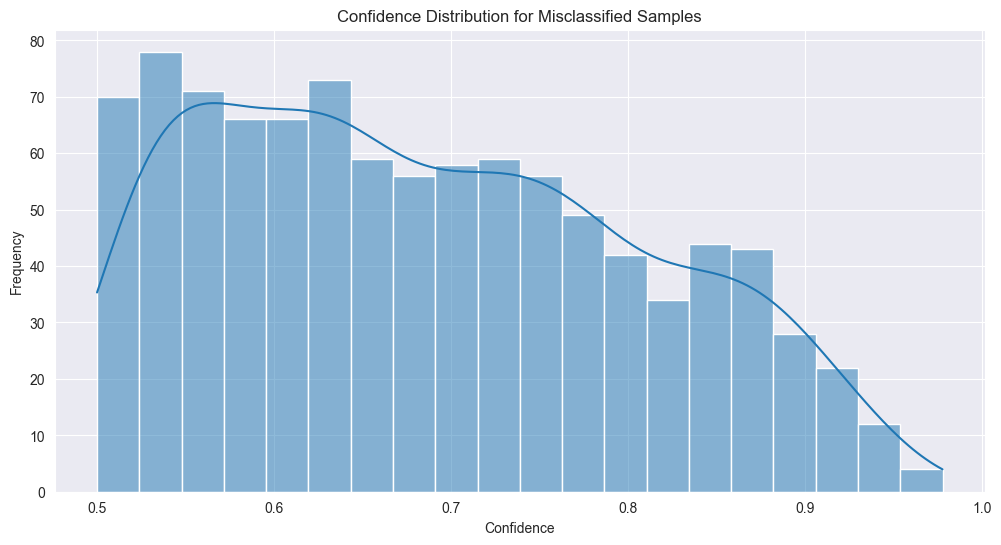

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(misclassifications_df["confidence"], bins=20, kde=True)
plt.title("Confidence Distribution for Misclassified Samples")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

In [19]:
import json
import ast


def extract_feature_importance(stage_row):
    feature_importance = stage_row["feature_importance"]

    # If feature_importance is a string, eval it safely
    if isinstance(feature_importance, str):
        feature_importance = eval(feature_importance, {"np": np})  # Allow np.float32 parsing

    # Convert np.float32 values to standard Python float
    feature_importance = {k: float(v) for k, v in feature_importance.items()}

    return pd.DataFrame(
        {"Feature": list(feature_importance.keys()),
         "Importance": list(feature_importance.values())}
    ).sort_values(by="Importance", ascending=False)


In [21]:
# Example: Analyze feature importance for a specific stage (e.g., Season 2015/2016 - 1, Stage 3)
target_stage = results_df[
    (results_df["season"] == "2015/2016 - 1") &
    (results_df["stage"] == 3)
]
target_stage
feature_importance_df = extract_feature_importance(target_stage.iloc[0])

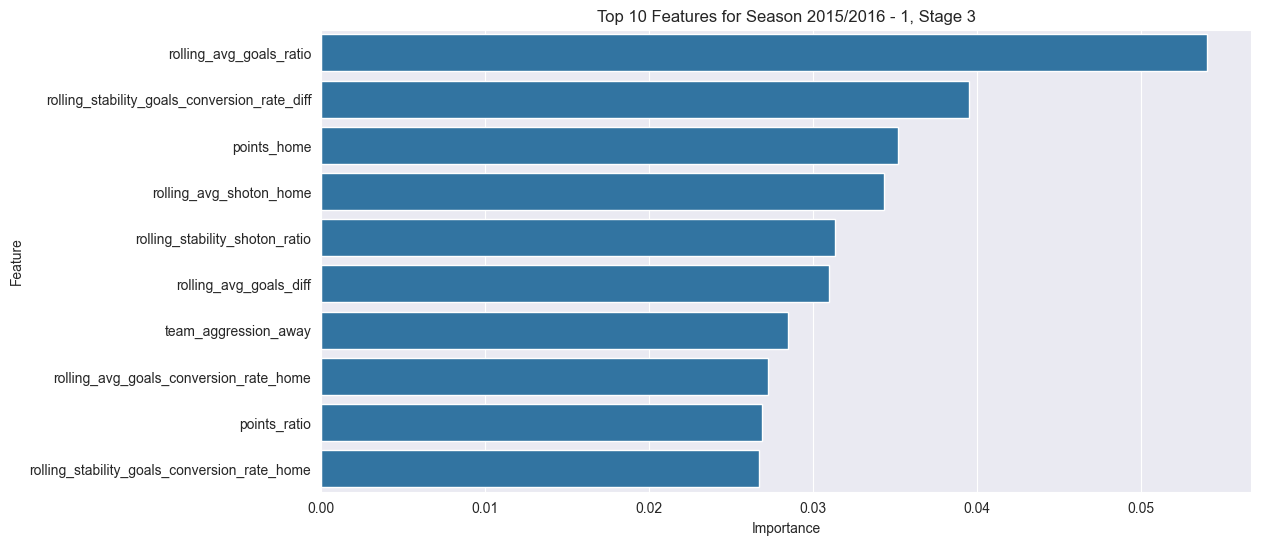

In [22]:
# Plot top features
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Features for Season 2015/2016 - 1, Stage 3")
plt.show()